# Does GDELT news add lift over the no-sentiment baseline?

**Question.** Holding the baseline design fixed (same rows, same temporal split, same
case-control weighting, same Random Forest), does adding GDELT GKG news-mention features
to the 23 RF-selected predictors improve out-of-time PR-AUC for
`target_outbreak_next_7d`?

**Source tables.** `model_county_day_gdelt` = the frozen `model_county_day` (23
predictors) + 12 GDELT columns (`sql/builds/model_county_day_gdelt.sql`). Baseline and
GDELT arms are read from the **same rows of the same table**, so a difference is
attributable to the added columns alone.

**Priors, stated before looking.** A weekly within-state correlation computed at load time
peaks at lag 0 / news-after-outbreak, i.e. news mostly *follows* APHIS confirmation, and
the baseline already carries own-county and neighbor outbreak history. Expect little lift
on all positives. The slice where news could plausibly help is **new-onset** positives
(no own-county outbreak in the prior 60 days), reported separately in section 5.

**Arms.**

| arm | predictors |
|---|---|
| A baseline | 23 |
| B + state + national GDELT | 23 + 9 |
| C + county GDELT | 23 + 3 |
| D + all GDELT | 23 + 12 |
| E + all GDELT, media hubs removed | 23 + 12, county layer zeroed for hub counties |

GDELT is news, not social media. A null here is a result about news coverage,
not about the social-media thesis.

In [1]:
# --- configuration: identical to regression_baseline.ipynb where it overlaps ---------
STUDY_START = "2022-02-08"
SPLIT_DATE  = "2025-01-01"
NEG_SAMPLE_RATE = 0.05
RANDOM_STATE    = 20260728

# Negatives are sampled by a HASH of (fips, day), not random(), so every arm and every
# re-run sees the same rows. 500 / 10000 = NEG_SAMPLE_RATE.
NEG_HASH_BUCKETS, NEG_HASH_KEEP = 10_000, 500

# RF hyperparameters from section 10.2 / 12 of the baseline notebook -- not re-tuned,
# so the comparison is not confounded by a search that favors one arm.
RF_PARAMS = dict(n_estimators=300, max_depth=6, min_samples_leaf=2, n_jobs=-1)
SEEDS = [RANDOM_STATE, RANDOM_STATE + 1, RANDOM_STATE + 2]

N_BOOT = 300   # week-block bootstrap reps for the paired difference

# Media-hub rule, decided before looking at lift: a county is a hub if its TRAIN-window
# GDELT county article count is in the top HUB_TOP_PCT of counties AND its poultry
# operations are below the national median. Urban dateline counties, not farm counties.
HUB_TOP_PCT = 0.01

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

from h5n1.db import get_engine

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# Same recessive style as regression_baseline.ipynb.
INK, INK_2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
BLUE = "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9.5,
    "lines.linewidth": 2.0, "legend.frameon": False,
})

## 1. Load

One query, one frame. Test period complete; training positives all kept; training negatives hash-sampled.

In [3]:
engine = get_engine()
build = pd.read_sql(
    "SELECT build_id, built_at, feature_set, n_rows, source_max_day, notes "
    "FROM model_build_log WHERE table_name IN ('model_county_day', 'model_county_day_gdelt') "
    "ORDER BY build_id DESC LIMIT 2", engine)
display(build)

QUERY = f'''
SELECT m.*, d.poultry_operations
FROM model_county_day_gdelt m
JOIN county_poultry_census d USING (fips)
WHERE m.is_conus
  AND m.target_complete_7d
  AND m.day >= '{STUDY_START}'
  AND (
        m.day >= '{SPLIT_DATE}'
     OR m.target_outbreak_next_7d
     OR mod(abs(hashtext(m.fips || m.day::text)), {NEG_HASH_BUCKETS}) < {NEG_HASH_KEEP}
      )
'''
df = pd.read_sql(QUERY, engine)
df["day"] = pd.to_datetime(df["day"])
train, test = df.day < SPLIT_DATE, df.day >= SPLIT_DATE
print(f"{len(df):,} rows; train {train.sum():,} ({df.loc[train,'target_outbreak_next_7d'].sum():,} pos), "
      f"test {test.sum():,} ({df.loc[test,'target_outbreak_next_7d'].sum():,} pos)")
print(f"test window {df.loc[test,'day'].min().date()} .. {df.loc[test,'day'].max().date()}")

,build_id,built_at,feature_set,n_rows,source_max_day,notes
0,5,2026-09-24 21:52:51.047101+00:00,rf23+gdelt,7524342,2026-07-21,Baseline model_county_day build_id 2 + 12 GDEL...
1,4,2026-09-24 18:40:00.680767+00:00,rf23+gdelt,7524342,2026-07-21,Baseline model_county_day build_id 2 + 12 GDEL...


1,912,811 rows; train 172,331 (8,136 pos), test 1,740,480 (4,366 pos)
test window 2025-01-01 .. 2026-07-14


## 2. Feature sets and preparation

In [4]:
KEYS = {"state", "fips", "day", "target_outbreak_next_7d", "target_complete_7d", "is_conus",
        "poultry_operations"}
GDELT_STATE = ["log_gdelt_state_articles_7d", "log_gdelt_state_articles_21d",
               "log_gdelt_state_stories_7d", "log_gdelt_state_stories_21d",
               "log_gdelt_state_per10k_7d", "log_gdelt_state_per10k_21d",
               "gdelt_state_tone_mean_21d", "gdelt_state_neg_share_21d"]
GDELT_US = ["log_gdelt_us_per10k_7d"]
GDELT_COUNTY = ["log_gdelt_county_articles_7d", "log_gdelt_county_articles_21d",
                "log_gdelt_county_stories_21d"]
GDELT_ALL = GDELT_STATE + GDELT_US + GDELT_COUNTY
BASE = [c for c in df.columns if c not in KEYS and c not in GDELT_ALL]
assert len(BASE) == 23, BASE
assert set(GDELT_ALL) <= set(df.columns)

# NULL audit before filling anything.
print("NULL share in study rows:")
print(df[BASE + GDELT_ALL].isna().mean().loc[lambda s: s > 0].map("{:.2%}".format).to_string())

NULL share in study rows:


days_since_outbreak_county       91.36%
days_since_outbreak_neighbor     65.58%
log_layer_inventory              11.21%
temp_min_7d_c                     0.16%
temp_max_7d_c                     0.16%
precip_7d_mm                      0.15%
log_gdelt_state_articles_7d       3.74%
log_gdelt_state_articles_21d      6.01%
log_gdelt_state_stories_7d        3.74%
log_gdelt_state_stories_21d       6.01%
log_gdelt_state_per10k_7d         3.74%
log_gdelt_state_per10k_21d        6.01%
gdelt_state_tone_mean_21d         7.45%
gdelt_state_neg_share_21d         7.45%
log_gdelt_us_per10k_7d            3.74%
log_gdelt_county_articles_7d      3.74%
log_gdelt_county_articles_21d     6.01%
log_gdelt_county_stories_21d      6.01%


### GDELT outage: excluded from every arm

GKG has **no records at all for 2025-06-15 .. 2025-07-01**. Any row whose trailing window
touches those days has NULL GDELT features (see the 014 header), because the source was
absent, which is not the same as zero news. Filling those rows would hand the forest a
value it never saw in training. They are dropped from **all** arms, so every arm is still
scored on identical rows. The baseline's score here is therefore on a slightly smaller test
set than `regression_baseline.ipynb`'s.

In [5]:
GDELT_COVER = [c for c in GDELT_ALL if c not in ("gdelt_state_tone_mean_21d", "gdelt_state_neg_share_21d")]
covered = df[GDELT_COVER].notna().all(axis=1)
drop = df[~covered]
print(f"dropped {len(drop):,} rows ({drop.target_outbreak_next_7d.sum():,} positives); "
      f"days {drop.day.min().date()} .. {drop.day.max().date()}; "
      f"train rows dropped: {(drop.day < SPLIT_DATE).sum():,}")
df = df[covered].reset_index(drop=True)
train, test = df.day < SPLIT_DATE, df.day >= SPLIT_DATE

dropped 114,996 rows (7 positives); days 2025-06-16 .. 2025-07-22; train rows dropped: 0


In [6]:
def prepare(frame):
    X = frame[BASE + GDELT_ALL].copy()
    # Baseline: train-window median fills, exactly as build_X() in regression_baseline.
    for c in ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm", "log_layer_inventory"]:
        X[c] = X[c].fillna(X.loc[frame.day < SPLIT_DATE, c].median())
    # Recency is right-censored (NULL = nothing in 365 days): same 400-day cap as build_X.
    for c in ["days_since_outbreak_county", "days_since_outbreak_neighbor"]:
        X[c] = X[c].fillna(4.0)
    # GDELT tone / negative share are NULL when the state had no stories in the window.
    # 0 is neutral tone and zero negative share; the stories_21d column already tells
    # the forest that the window was empty, so no separate indicator is needed.
    X[["gdelt_state_tone_mean_21d", "gdelt_state_neg_share_21d"]] = \
        X[["gdelt_state_tone_mean_21d", "gdelt_state_neg_share_21d"]].fillna(0.0)
    # Everything else was made non-NULL by the outage filter above; asserted rather
    # than filled, so a new gap fails loudly instead of being imputed.
    left = X.columns[X.isna().any()].tolist()
    assert not left, f"unexpected NULLs: {left}"
    return X

X = prepare(df)
y = df.target_outbreak_next_7d.astype(int).to_numpy()
w_tr = np.where(y[train] == 1, 1.0, 1.0 / NEG_SAMPLE_RATE)   # case-control weights

### Media hubs

Rule fixed in the config cell, computed on the **training window only** so the choice
can't see the test period.

In [7]:
tr_cnt = (np.expm1(df.loc[train, "log_gdelt_county_articles_7d"])
            .groupby(df.loc[train, "fips"]).sum())
# Training negatives are sampled, so this count is a relative ranking, not a total.
cut = tr_cnt.quantile(1 - HUB_TOP_PCT)
pops = df.drop_duplicates("fips").set_index("fips")["poultry_operations"]
hubs = sorted(set(tr_cnt[tr_cnt >= cut].index) & set(pops[pops < pops.median()].index))

names = pd.read_sql("SELECT fips, county_name, state FROM dim_county", engine).set_index("fips")
hub_tbl = names.loc[hubs].assign(train_mentions_rank=tr_cnt.rank(ascending=False).loc[hubs].astype(int),
                                 poultry_operations=pops.loc[hubs].astype(int))
print(f"{len(hubs)} hub counties (top {HUB_TOP_PCT:.0%} by train-window county mentions, "
      f"poultry ops < median {pops.median():.0f}):")
display(hub_tbl.sort_values("train_mentions_rank"))

X_nohub = X.copy()
X_nohub.loc[df.fips.isin(hubs).to_numpy(), GDELT_COUNTY] = 0.0

8 hub counties (top 1% by train-window county mentions, poultry ops < median 59):


,county_name,state,train_mentions_rank,poultry_operations
fips,,,,
11001,District of Columbia,DC,1,0
19021,Buena Vista County,IA,6,43
17031,Cook County,IL,17,22
55079,Milwaukee County,WI,25,16
19079,Hamilton County,IA,26,55
42101,Philadelphia County,PA,27,4
25025,Suffolk County,MA,31,6
19173,Taylor County,IA,32,31


## 3. Fit every arm, three seeds each

In [8]:
ARMS = {
    "A baseline":              (X, BASE),
    "B +state/national":       (X, BASE + GDELT_STATE + GDELT_US),
    "C +county":               (X, BASE + GDELT_COUNTY),
    "D +all GDELT":            (X, BASE + GDELT_ALL),
    "E +all, hubs removed":    (X_nohub, BASE + GDELT_ALL),
}

y_te = y[test.to_numpy()]
base_rate = y_te.mean()
preds, rows, importances = {}, [], {}
for arm, (Xa, cols) in ARMS.items():
    ps = []
    for seed in SEEDS:
        rf = RandomForestClassifier(random_state=seed, **RF_PARAMS)
        rf.fit(Xa.loc[train, cols], y[train.to_numpy()], sample_weight=w_tr)
        p = rf.predict_proba(Xa.loc[test, cols])[:, 1]
        ps.append(p)
        rows.append({"arm": arm, "seed": seed, "n_pred": len(cols),
                     "pr_auc": average_precision_score(y_te, p),
                     "roc_auc": roc_auc_score(y_te, p)})
        if seed == SEEDS[0]:
            importances[arm] = pd.Series(rf.feature_importances_, index=cols)
    preds[arm] = np.mean(ps, axis=0)   # seed-averaged score for the bootstrap
    print(f"{arm:24s} done")

res = pd.DataFrame(rows)
summary = (res.groupby("arm", sort=False)
              .agg(n_pred=("n_pred", "first"),
                   pr_auc=("pr_auc", "mean"), pr_auc_sd=("pr_auc", "std"),
                   roc_auc=("roc_auc", "mean")))
summary["lift_x"] = summary.pr_auc / base_rate
print(f"test rows {len(y_te):,}, positives {y_te.sum():,}, base rate {base_rate:.4%}")
display(summary.style.format({"pr_auc": "{:.4f}", "pr_auc_sd": "{:.4f}",
                              "roc_auc": "{:.4f}", "lift_x": "{:.1f}"}))

A baseline               done


B +state/national        done


C +county                done


D +all GDELT             done


E +all, hubs removed     done
test rows 1,625,484, positives 4,359, base rate 0.2682%


,n_pred,pr_auc,pr_auc_sd,roc_auc,lift_x
arm,,,,,
A baseline,23,0.1411,0.0020,0.8649,52.6
B +state/national,32,0.1289,0.0018,0.8603,48.1
C +county,26,0.1391,0.0014,0.8673,51.9
D +all GDELT,35,0.1310,0.0002,0.8638,48.8
"E +all, hubs removed",35,0.1299,0.0009,0.8635,48.4


## 4. Is the difference real? Paired week-block bootstrap

Seed spread only measures forest randomness. The bigger uncertainty is *which weeks*
landed in the test window, since outbreaks cluster in waves. Resample whole ISO weeks
of the test period with replacement, and recompute every arm's PR-AUC on the same resample.
The difference vs A is paired, so shared wave-to-wave noise cancels.

In [9]:
wk = df.loc[test, "day"].dt.to_period("W").astype(str).to_numpy()
weeks = np.unique(wk)
idx_by_week = {w: np.flatnonzero(wk == w) for w in weeks}
rng = np.random.default_rng(RANDOM_STATE)

boot = {arm: [] for arm in ARMS}
for _ in range(N_BOOT):
    pick = rng.choice(weeks, size=len(weeks), replace=True)
    ix = np.concatenate([idx_by_week[w] for w in pick])
    if y_te[ix].sum() == 0:
        continue
    for arm in ARMS:
        boot[arm].append(average_precision_score(y_te[ix], preds[arm][ix]))
boot = pd.DataFrame(boot)

point = {arm: average_precision_score(y_te, preds[arm]) for arm in ARMS}
diff = boot.sub(boot["A baseline"], axis=0).drop(columns="A baseline")
ci = pd.DataFrame({
    "pr_auc (seed-avg)": pd.Series(point),
    "delta vs A": pd.Series(point) - point["A baseline"],
    "delta 2.5%": diff.quantile(0.025),
    "delta 97.5%": diff.quantile(0.975),
    "P(delta > 0)": (diff > 0).mean(),
})
print(f"{len(boot)} bootstrap reps over {len(weeks)} test weeks")
display(ci.style.format("{:.4f}", na_rep="--"))

300 bootstrap reps over 76 test weeks


,pr_auc (seed-avg),delta vs A,delta 2.5%,delta 97.5%,P(delta > 0)
A baseline,0.1411,0.0000,--,--,--
B +state/national,0.1296,-0.0115,-0.0175,-0.0046,0.0000
C +county,0.1392,-0.0019,-0.0049,0.0019,0.1833
D +all GDELT,0.1318,-0.0093,-0.0152,-0.0027,0.0033
"E +all, hubs removed",0.1305,-0.0106,-0.0169,-0.0041,0.0033


findfont: Failed to find font weight 600, now using 700.


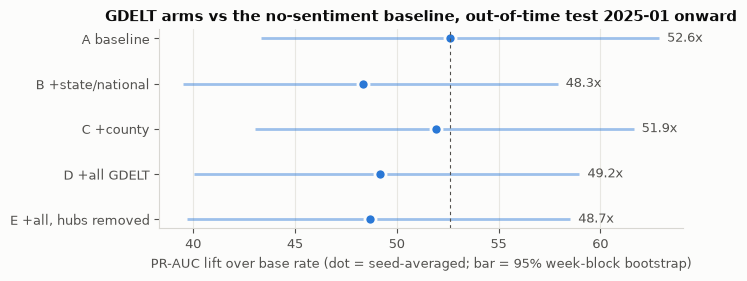

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 2.9))
arms = list(ARMS)
yy = np.arange(len(arms))[::-1]
lo = boot.quantile(0.025) / base_rate
hi = boot.quantile(0.975) / base_rate
mid = pd.Series(point) / base_rate
ax.hlines(yy, lo[arms], hi[arms], color=BLUE, linewidth=2, alpha=0.45)
ax.plot(mid[arms], yy, "o", color=BLUE, markersize=8,
        markeredgecolor=SURFACE, markeredgewidth=2)
ax.axvline(mid["A baseline"], color=INK_2, linewidth=0.8, linestyle=(0, (3, 3)))
for yi, a in zip(yy, arms):
    ax.text(hi[a], yi, f"  {mid[a]:.1f}x", va="center", color=INK_2, fontsize=9)
ax.set_yticks(yy, arms)
ax.set_xlabel("PR-AUC lift over base rate (dot = seed-averaged; bar = 95% week-block bootstrap)")
ax.set_title("GDELT arms vs the no-sentiment baseline, out-of-time test 2025-01 onward")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 5. The early-warning slice: new-onset positives

A baseline dominated by own-county history is strong at "outbreaks continue" and
weak at "outbreak arrives". This restricts the test set to county-days with **no own-county
outbreak in the prior 60 days**, which is where a leading news signal would have to show up.

In [11]:
onset = (df.loc[test, "log_own_outbreaks_60d"].to_numpy() == 0)
y_on = y_te[onset]
br_on = y_on.mean()
bo = {arm: [] for arm in ARMS}
wk_on = wk[onset]
idx_on = {w: np.flatnonzero(wk_on == w) for w in np.unique(wk_on)}
wk_list = list(idx_on)
for _ in range(N_BOOT):
    ix = np.concatenate([idx_on[w] for w in rng.choice(wk_list, size=len(wk_list), replace=True)])
    if y_on[ix].sum() == 0:
        continue
    for arm in ARMS:
        bo[arm].append(average_precision_score(y_on[ix], preds[arm][onset][ix]))
bo = pd.DataFrame(bo)
d_on = bo.sub(bo["A baseline"], axis=0).drop(columns="A baseline")
pt_on = pd.Series({arm: average_precision_score(y_on, preds[arm][onset]) for arm in ARMS})
print(f"new-onset slice: {onset.sum():,} rows, {y_on.sum():,} positives, base rate {br_on:.4%}")
display(pd.DataFrame({
    "pr_auc": pt_on, "lift_x": pt_on / br_on, "delta vs A": pt_on - pt_on["A baseline"],
    "delta 2.5%": d_on.quantile(0.025), "delta 97.5%": d_on.quantile(0.975),
    "P(delta > 0)": (d_on > 0).mean(),
}).style.format("{:.4f}", na_rep="--"))

new-onset slice: 1,592,897 rows, 2,966 positives, base rate 0.1862%


,pr_auc,lift_x,delta vs A,delta 2.5%,delta 97.5%,P(delta > 0)
A baseline,0.0146,7.8602,0.0000,--,--,--
B +state/national,0.0147,7.8762,0.0000,-0.0007,0.0012,0.5500
C +county,0.0153,8.2304,0.0007,-0.0000,0.0015,0.9700
D +all GDELT,0.0150,8.0449,0.0003,-0.0008,0.0013,0.7600
"E +all, hubs removed",0.0148,7.9440,0.0002,-0.0010,0.0010,0.6567


## 6. Where the forest put the GDELT signal (arm D, first seed)

In [12]:
imp = importances["D +all GDELT"].sort_values(ascending=False)
share = imp[GDELT_ALL].sum()
print(f"GDELT columns hold {share:.1%} of total impurity importance in arm D")
display(imp.to_frame("importance").assign(
    gdelt=lambda t: t.index.isin(GDELT_ALL)).head(20).style.format({"importance": "{:.4f}"}))

GDELT columns hold 25.8% of total impurity importance in arm D


,importance,gdelt
log_own_outbreaks_7d,0.1002,False
days_since_outbreak_county,0.0996,False
log_own_outbreaks_21d,0.0736,False
log_own_outbreaks_60d,0.0452,False
days_since_outbreak_neighbor,0.0312,False
log_layer_inventory,0.0295,False
log_poultry_operations,0.0284,False
log_nbr_infections_7d,0.0267,False
log_turkey_operations,0.0264,False
log_wintering_side_pressure,0.0258,False


## 7. Reading the result

Read the tables above against these rules, which were set before the run:

- **A lift claim needs the week-block 95% interval for "delta vs A" to exclude 0**, not
  just a higher point estimate. Seed SD alone is not evidence.
- **Section 5 is the result that matters for the early-warning thesis.** A gain on all
  positives that vanishes on new-onset positives means GDELT is re-describing outbreaks
  the baseline already knows about.
- **Impurity importance (section 6) is not evidence of lift.** Correlated news columns can
  soak up importance from outbreak-history columns without improving prediction.
- **Arm E vs D** tests the media-hub caveat. If removing hubs changes nothing, the county
  layer was never contributing anyway.

Caveats: test rows touching the 2025-06-15..07-01 GDELT outage are excluded from every
arm (section 2). The GDELT day key is the processing batch, not the publication time. All
windows are past-only. The test window (2025 onward) contains the largest news spike in
the series (Jan–Mar 2025, egg prices), so state-level news volume there partly reflects
economics rather than local outbreak risk.